# 06 — Clustering Temporal (Fase 2F)

Agrupamos pacientes por su **vector de trayectoria** (pendientes, niveles, volatilidad y CES). Comparamos **KMeans, GMM, Agglomerative y DBSCAN** (silhouette, Davies-Bouldin) y caracterizamos los perfiles resultantes.

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


In [2]:
clu = load(MET/'clustering.json')
print('Mejor método:', clu['best_method'])
pd.DataFrame(clu['comparison']).round(3)

Mejor método: DBSCAN


,method,silhouette,davies_bouldin,n_clusters,n_noise,ari_vs_arquetipo
0,KMeans,0.432,0.983,4,0,0.757
1,GMM,0.420,1.097,4,0,0.793
2,Agglomerative,0.427,0.985,4,0,0.753
3,DBSCAN,0.496,0.861,7,40,0.924


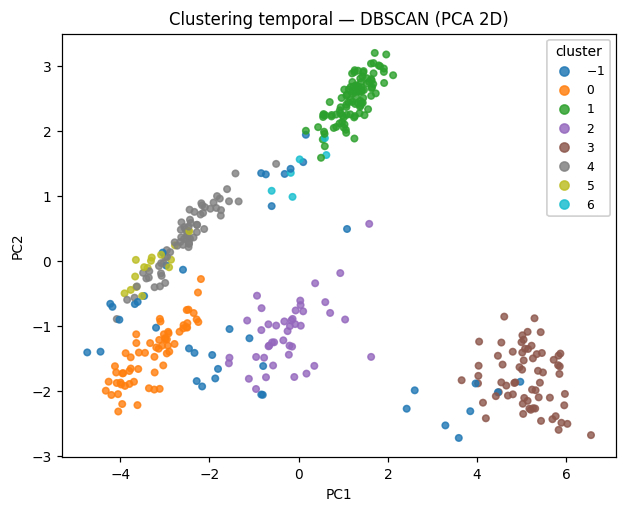

In [3]:
show(FIG/'clustering'/'clusters_pca.png')

## Perfiles encontrados
Cada cluster se caracteriza por su CES medio, pendientes y el arquetipo dominante (pureza).

In [4]:
pd.read_csv(MET/'cluster_profiles.csv')

,cluster,n,ces_mean,glucosa_slope_m,imc_slope_m,riesgo_slope_m,arquetipo_dominante,pureza
0,3,66,78.4,-6.53,-0.343,-0.0588,Mejora rápida,1.00
1,1,103,63.2,0.34,0.001,0.0026,Estable,1.00
2,2,43,37.0,0.42,-0.003,0.0023,Oscilante,1.00
3,6,6,34.2,7.58,0.009,0.0505,Estable,1.00
4,-1,40,29.8,5.35,-0.023,0.0324,Oscilante,0.33
5,0,62,19.6,2.98,0.051,0.0027,Alto riesgo persistente,1.00
6,4,65,17.0,5.03,0.203,0.0591,Deterioro lento,1.00
7,5,15,11.4,14.11,0.191,0.0812,Deterioro lento,1.00


### Conclusión 2F
El clustering **recupera perfiles clínicos interpretables** (mejoran rápido / estables / empeoran / alto riesgo persistente), validado contra los arquetipos por ARI (NB 08).